# Neural Network From Scratch — XOR Problem

In this exercise you will implement a complete 2-layer neural network using only NumPy,
including forward propagation, backpropagation, and gradient descent.
The task is to learn the XOR function.

Complete each TODO before moving to the next cell.

## Key Concept: How a Neural Network Learns

A neural network transforms inputs to outputs through alternating
**linear transformations** (matrix multiplications) and **non-linear activations**.
Without non-linearities, stacking layers is equivalent to a single linear map — it
could never solve XOR.

**Why this 2-layer network can learn XOR:**
The hidden layer (4 neurons) learns a *non-linear feature space* where the two classes
become linearly separable. The output layer then draws a linear boundary in that space.

**The learning loop — four repeated steps:**
1. **Forward pass** — compute predictions from current weights
2. **Loss** — measure how wrong the predictions are
3. **Backward pass** — use the chain rule to compute ∂Loss/∂weight for every weight
4. **Gradient descent** — nudge each weight in the direction that reduces loss

**Shape intuition for this network (batch of 4 samples):**
```
X          (4, 2)
  × W1     (2, 4)  → z1  (4, 4)  → a1  (4, 4)
  × W2     (4, 1)  → z2  (4, 1)  → a2  (4, 1)  ← predictions
```

> 📖 [Karpathy — A Recipe for Training Neural Networks](http://karpathy.github.io/2019/04/25/recipe/)

## Step 1: Import Libraries

In [ ]:
import numpy as np

## Step 2: Define the Dataset

XOR truth table:
- Input (0,0) → Output 0
- Input (0,1) → Output 1
- Input (1,0) → Output 1
- Input (1,1) → Output 0

Create `X` with shape `(4, 2)` and `y` with shape `(4, 1)`.

In [ ]:
# TODO: Create X as a numpy array with the 4 XOR input pairs (shape 4x2)
X = ...

# TODO: Create y as a numpy array with the 4 XOR outputs (shape 4x1)
y = ...

## Step 3: Initialize Weights and Biases

Our network: 2 inputs → 4 hidden neurons → 1 output
- `W1`: shape `(2, 4)` — weights from input to hidden layer
- `b1`: shape `(1, 4)` — bias for hidden layer (initialize to zeros)
- `W2`: shape `(4, 1)` — weights from hidden to output
- `b2`: shape `(1, 1)` — bias for output (initialize to zeros)

Use `np.random.seed(42)` and `np.random.randn` for weight initialization.

In [ ]:
np.random.seed(42)

# TODO: Initialize W1 with shape (2, 4) using np.random.randn
W1 = ...

# TODO: Initialize b1 with shape (1, 4) as zeros
b1 = ...

# TODO: Initialize W2 with shape (4, 1) using np.random.randn
W2 = ...

# TODO: Initialize b2 with shape (1, 1) as zeros
b2 = ...

## Step 4: Define Activation Functions

We use the **sigmoid** function: `σ(x) = 1 / (1 + e^{-x})`

Its derivative: `σ'(x) = σ(x) · (1 - σ(x))`

Implement both functions below.

In [ ]:
def sigmoid(x):
    # TODO: return the sigmoid of x
    pass

def sigmoid_derivative(x):
    # TODO: return the derivative of sigmoid at x
    # Hint: sigmoid(x) * (1 - sigmoid(x))
    pass

# Test: sigmoid(0) should be 0.5
print(sigmoid(0))

## Step 5: Forward Pass

Compute the forward pass step by step:
1. `z1 = X @ W1 + b1`
2. `a1 = sigmoid(z1)`
3. `z2 = a1 @ W2 + b2`
4. `a2 = sigmoid(z2)`

Return all intermediate values — you'll need them for backprop.

In [ ]:
def forward(X, W1, b1, W2, b2):
    # TODO: compute z1, a1, z2, a2
    z1 = ...
    a1 = ...
    z2 = ...
    a2 = ...
    return z1, a1, z2, a2

# Test it
z1, a1, z2, a2 = forward(X, W1, b1, W2, b2)
print('a2 shape:', a2.shape)
print('a2 (initial predictions):', a2)

## Step 6: Compute Loss (Binary Cross-Entropy)

Binary cross-entropy loss:

```
L = -1/n · Σ [ y·log(a2) + (1-y)·log(1-a2) ]
```

This measures how far our predictions are from the true labels.

In [ ]:
def compute_loss(y, a2):
    # TODO: compute and return the binary cross-entropy loss
    # Use np.mean. Add 1e-8 to log arguments to avoid log(0).
    pass

# Test it
loss = compute_loss(y, a2)
print('Initial loss:', loss)

### Concept Check: Forward Pass & Loss

**Q1.** After the forward pass, `a2` has shape `(4, 1)`.
Why is `y` also shaped `(4, 1)` rather than `(4,)`?
What silent broadcasting error would occur if `y` were `(4,)`?

**Q2.** Binary cross-entropy is `-mean(y*log(a2) + (1-y)*log(1-a2))`.
If the true label is 1 and the model predicts 0.01, what is the loss for that sample?
What does this tell you about how BCE penalises confident wrong predictions?

**Q3.** Why do we add `1e-8` inside the logarithm?

In [ ]:
# Q1:
# Q2:
# Q3:


## Step 7: Backward Pass (Backpropagation)

Using the chain rule, compute gradients from output back to input:

**Output layer:**
- `dL_da2 = -(y/a2 - (1-y)/(1-a2)) / n`
- `dL_dz2 = dL_da2 * sigmoid_derivative(z2)`
- `dW2 = a1.T @ dL_dz2`
- `db2 = np.sum(dL_dz2, axis=0, keepdims=True)`

**Hidden layer:**
- `dL_da1 = dL_dz2 @ W2.T`
- `dL_dz1 = dL_da1 * sigmoid_derivative(z1)`
- `dW1 = X.T @ dL_dz1`
- `db1 = np.sum(dL_dz1, axis=0, keepdims=True)`

In [ ]:
def backward(X, y, z1, a1, z2, a2, W1, W2):
    n = X.shape[0]

    # Output layer gradients
    dL_da2 = ...
    dL_dz2 = ...
    dW2 = ...
    db2 = ...

    # Hidden layer gradients
    dL_da1 = ...
    dL_dz1 = ...
    dW1 = ...
    db1 = ...

    return dW1, db1, dW2, db2

## Step 8: Parameter Update (Gradient Descent)

Update each parameter by subtracting a fraction of its gradient:

`W = W - learning_rate × dW`

In [ ]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, lr=0.1):
    # TODO: update and return all four parameters
    W1 = ...
    b1 = ...
    W2 = ...
    b2 = ...
    return W1, b1, W2, b2

## Step 9: Training Loop

Put it all together: forward pass → compute loss → backward pass → update parameters.
Repeat for 10,000 epochs.

In [ ]:
losses = []
for epoch in range(10000):
    # TODO: forward pass

    # TODO: compute loss and append to losses

    # TODO: backward pass

    # TODO: update parameters

    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss:.4f}')

### Concept Check: Backpropagation & Gradient Descent

**Q1.** In `backward()`, gradients are divided by `n = X.shape[0]`.
Why? What would happen if you trained on batches of different sizes without this?

**Q2.** `dW2 = a1.T @ dL_dz2`.
`a1` is `(4, 4)` and `dL_dz2` is `(4, 1)`.
Verify the resulting shape matches `W2`, and explain *why* this formula is correct
(hint: think about which quantities are multiplied in the forward pass).

**Q3.** The vanishing gradient problem: `sigmoid'(x) ≤ 0.25` always.
If you had 10 hidden sigmoid layers, what order of magnitude would the gradient
reaching the first layer be? How do modern networks avoid this?

In [ ]:
# Q1:
# Q2:
# Q3:


## Step 10: Evaluate Predictions

Run the final forward pass and round the output probabilities to get binary predictions.

In [ ]:
# TODO: run forward pass on X
# Round a2 to get predicted classes
# Print X, true y, and predicted y

print('Input X:')
print(X)
print('True y:   ', y.flatten().astype(int))
print('Predicted:', ...)

## Step 11: Visualize the Network Architecture

Each node represents a neuron. Line color/opacity represents connection strength.

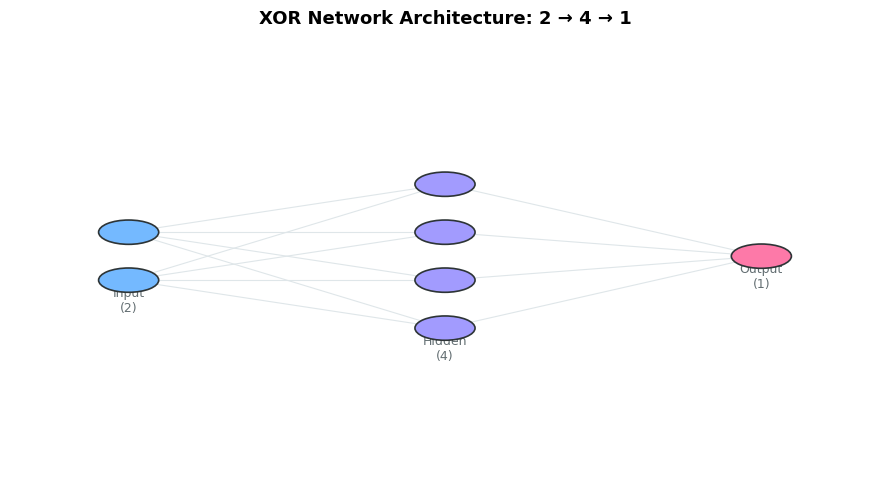

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def draw_network(layer_sizes, layer_labels=None, title='', figsize=(9, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.2, 1.2)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    n = len(layer_sizes)
    xs = np.linspace(0.1, 0.9, n)
    max_n = max(layer_sizes)
    gap = min(0.15, 0.85 / max(max_n, 2))
    colors = ['#74b9ff', '#a29bfe', '#fd79a8', '#55efc4', '#ffeaa7']
    ys_all = []
    for sz in layer_sizes:
        ys = [0.5 + (i - (sz - 1) / 2) * gap for i in range(sz)]
        ys_all.append(ys)
    for li in range(n - 1):
        for ya in ys_all[li]:
            for yb in ys_all[li + 1]:
                ax.plot([xs[li], xs[li + 1]], [ya, yb], color='#dfe6e9', lw=0.8, zorder=1)
    for li, (x, ys) in enumerate(zip(xs, ys_all)):
        for y in ys:
            c = plt.Circle((x, y), 0.038, fc=colors[li % len(colors)], ec='#2d3436', lw=1.2, zorder=5)
            ax.add_patch(c)
        lab = layer_labels[li] if layer_labels else str(layer_sizes[li])
        ax.text(x, min(ys) - 0.1, lab, ha='center', fontsize=9, color='#636e72')
    plt.tight_layout()
    plt.show()

draw_network(
    [2, 4, 1],
    layer_labels=['Input\n(2)', 'Hidden\n(4)', 'Output\n(1)'],
    title='XOR Network Architecture: 2 → 4 → 1'
)

## Step 12: Plot Training Loss

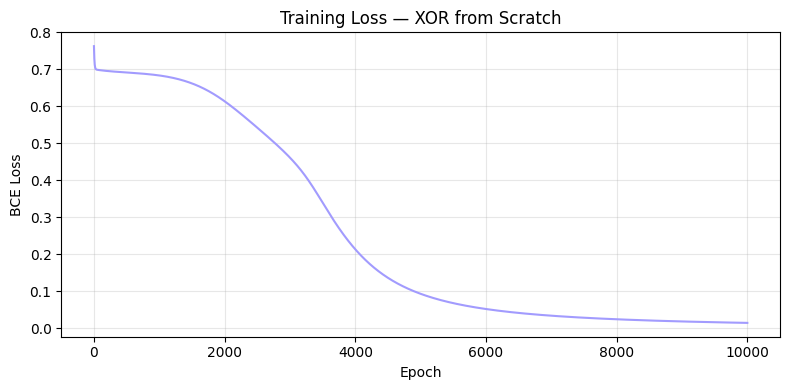

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(losses, color='#a29bfe', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training Loss — XOR from Scratch')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()